<a href="https://colab.research.google.com/github/sagarali110/quiz2/blob/main/IDS_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

data_path = "//content/drive/MyDrive/NIDS_Project/requirements.txt/dataset.csv/KDDTrain+.txt"

# Load the dataset
data = pd.read_csv(data_path)

# Show first few rows
print("✅ Dataset loaded successfully!\n")
print("Shape:", data.shape)
data.head()


✅ Dataset loaded successfully!

Shape: (125972, 43)


,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,...,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [ ]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Step 2: Load the training and testing datasets from Drive
train_path = '/content/drive/MyDrive/NIDS_Project/requirements.txt/dataset.csv/KDDTrain+.txt'
test_path = '/content/drive/MyDrive/NIDS_Project/requirements.txt/dataset.csv/KDDTest+.txt'

# Load the data (no header provided in dataset, so we'll specify column names)
col_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment',
    'urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted',
    'num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty_level'
]

train_data = pd.read_csv(train_path, names=col_names)
test_data = pd.read_csv(test_path, names=col_names)

print("✅ Datasets loaded successfully!")
print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

# Step 3: Encode categorical features
categorical_cols = ['protocol_type', 'service', 'flag']
encoder = LabelEncoder()

for col in categorical_cols:
    train_data[col] = encoder.fit_transform(train_data[col])
    test_data[col] = encoder.fit_transform(test_data[col])

print("✅ Categorical columns encoded!")

# Step 4: Create binary target variable (Normal=0, Attack=1)
train_data['Target'] = train_data['label'].apply(lambda x: 0 if x == 'normal' else 1)
test_data['Target'] = test_data['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Step 5: Drop unnecessary columns
X_train = train_data.drop(['label', 'Target', 'difficulty_level'], axis=1)
X_test = test_data.drop(['label', 'Target', 'difficulty_level'], axis=1)

y_train = train_data['Target']
y_test = test_data['Target']

# Step 6: Normalize features
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✅ Data normalization completed!")
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)


✅ Datasets loaded successfully!
Training data shape: (125973, 43)
Testing data shape: (22544, 43)
✅ Categorical columns encoded!
✅ Data normalization completed!
Training feature shape: (125973, 41)
Testing feature shape: (22544, 41)


In [ ]:
# Step 4: Build the Neural Network Model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the model architecture
model = Sequential([
    Dense(64, input_shape=(X_train.shape[1],), activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer (binary classification)
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Summary of the model
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,313 (20.75 KB)

 Trainable params: 5,313 (20.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 5: Train the model
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)


Epoch 1/15
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9430 - loss: 0.1620 - val_accuracy: 0.7716 - val_loss: 0.8141
Epoch 2/15
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9809 - loss: 0.0495 - val_accuracy: 0.7716 - val_loss: 0.8986
Epoch 3/15
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9860 - loss: 0.0370 - val_accuracy: 0.7813 - val_loss: 1.0199
Epoch 4/15
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9883 - loss: 0.0310 - val_accuracy: 0.7676 - val_loss: 1.1940
Epoch 5/15
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9899 - loss: 0.0277 - val_accuracy: 0.7899 - val_loss: 1.0832
Epoch 6/15
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9909 - loss: 0.0262 - val_accuracy: 0.7885 - val_loss: 1.1537
Epoch 7/15
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9907 - loss: 0.0248 - val_accuracy: 0.7688 - val_loss: 1.2510
Epoch 8/15
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9915 - loss: 0.0241 - 

In [ ]:
# Step 6: Evaluate model performance
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\n✅ Model Evaluation Complete!")
print(f"Test Accuracy: {accuracy * 100:.2f}%")


705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7837 - loss: 1.2932

✅ Model Evaluation Complete!
Test Accuracy: 77.85%


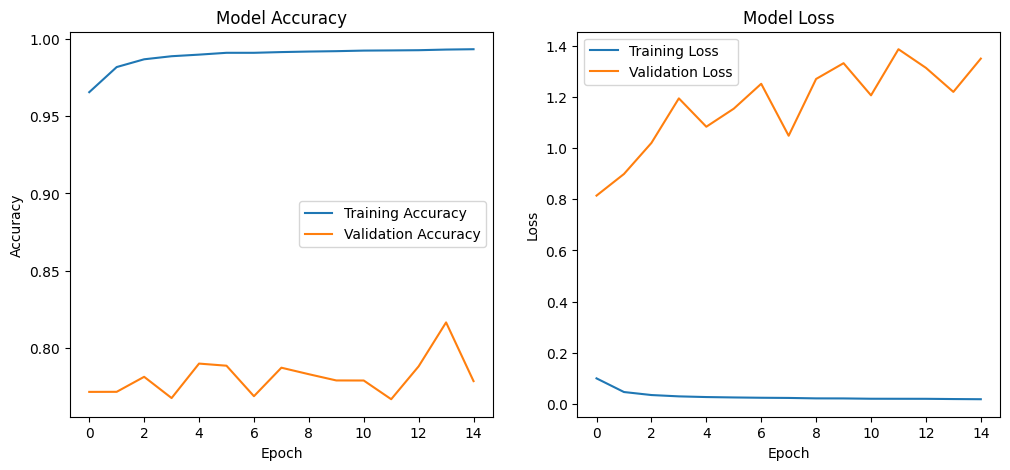

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


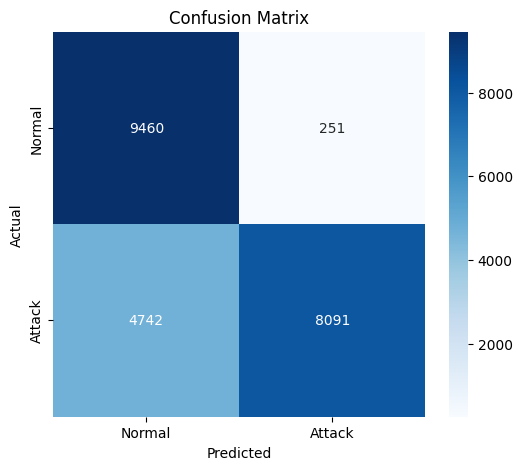

Classification Report:

              precision    recall  f1-score   support

      Normal       0.67      0.97      0.79      9711
      Attack       0.97      0.63      0.76     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.78     22544



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predict on test data
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))


In [ ]:
# Step 6: Save the trained model to Drive
model_save_path = '/content/drive/MyDrive/NIDS_Project/model/nids_model.h5'
model.save(model_save_path)

print(f"✅ Model saved successfully at: {model_save_path}")


✅ Model saved successfully at: /content/drive/MyDrive/NIDS_Project/model/nids_model.h5


In [ ]:
# Step 7: Load the saved model
from tensorflow.keras.models import load_model

model_load_path = '/content/drive/MyDrive/NIDS_Project/model/nids_model.h5'
loaded_model = load_model(model_load_path)

print("✅ Model loaded successfully!")

# Verify the accuracy again
loss, accuracy = loaded_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


✅ Model loaded successfully!
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7837 - loss: 1.2932
Test Accuracy: 77.85%


In [ ]:
import numpy as np

# Example: A new network record (randomly chosen from NSL-KDD feature pattern)
# Format must match your training features count (i.e., X_train.shape[1])
new_sample = np.array([[0, 1, 25, 1, 181, 5450, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 511, 511,
                        0.00, 0.00, 0.00, 0.00, 1.00, 0.00, 0.00, 255, 255, 1.00, 0.00, 0.00, 0.00, 0.00,
                        0.00, 0.00, 0.00, 0.00]])

# Use the loaded model to predict
prediction = loaded_model.predict(new_sample)

if prediction > 0.5:
    print("🚨 ALERT: Possible Intrusion Detected (Attack)")
else:
    print("✅ Normal Network Activity Detected")


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense" is incompatible with the layer: expected axis -1 of input shape to have value 41, but received input with shape (1, 42)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(1, 42), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>